In [266]:
import importlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

import activation, loss, layer, model
importlib.reload(activation)
importlib.reload(loss)
importlib.reload(layer)
importlib.reload(model)

from activation import Linear, ReLU, Sigmoid, Tanh, Softmax
from loss import BinaryCrossEntropy
from layer import DenseLayer
from model import Neural_Network

In [267]:
def preprocess_data(file_path):
    df = pd.read_csv(file_path)
    
    X = df.drop(columns=['placement_status'])
    y = df['placement_status']
    
    categorical_cols = X.select_dtypes(include=['object']).columns
    X = pd.get_dummies(X, columns=categorical_cols)
    
    scaler = StandardScaler()
    numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    X = X.astype(np.float64)
    
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y).astype(np.float64)
    y_binary = y_encoded.reshape(-1, 1)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X.to_numpy(dtype=np.float64),
        y_binary,
        test_size=0.2,
        random_state=SEED,
        stratify=y_encoded
    )
    
    return X_train, X_test, y_train, y_test, label_encoder

X_train, X_test, y_train, y_test, label_encoder = preprocess_data('datasetml_2026.csv')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train positive rate: {y_train.mean():.4f}, y_test positive rate: {y_test.mean():.4f}')

X_train: (8000, 28), X_test: (2000, 28)
y_train positive rate: 0.6152, y_test positive rate: 0.6155


In [268]:
def reset_seed(seed=SEED):
    np.random.seed(seed)
    random.seed(seed)

def build_network(layers, activations, init_method='uniform', init_params=None, seed=None, **kwargs):
    base_params = {'low': -0.3, 'high': 0.3} if init_params is None else dict(init_params)
    network = Neural_Network()
    
    for i in range(len(layers) - 1):
        act = activations[i] if i < len(activations) else Sigmoid()
        layer_params = dict(base_params)
        if seed is not None:
            layer_params['seed'] = seed + i
        network.add(DenseLayer(layers[i], layers[i+1], act, init_method, layer_params, **kwargs))
    return network

def run_experiment(name, model, epochs=40, lr=0.01, batch_size=32, verbose=0, seed=None, **kwargs):
    print(f"Running {name}...")
    if seed is not None:
        reset_seed(seed)
    history = model.train(X_train, y_train, loss=BinaryCrossEntropy(), 
                          epochs=epochs, learning_rate=lr, batch_size=batch_size, 
                          x_val=X_test, y_val=y_test, verbose=verbose)
    
    y_prob = model.predict(X_test).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_test.reshape(-1).astype(int)

    metrics = {
        'experiment': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else np.nan,
        **kwargs 
    }
    
    return {'model': model, 'history': history, 'metrics': metrics, 'prob': y_prob, 'pred': y_pred}

def plot_history_collection(results, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, res in results.items():
        axes[0].plot(res['history']['train_loss'], label=name)
        axes[1].plot(res['history']['val_loss'], label=name)
    
    for ax, t in zip(axes, ['Training Loss', 'Validation Loss']):
        ax.set_title(f"{title} - {t}"); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

def results_to_dataframe(results):
    df = pd.DataFrame([res['metrics'] for res in results.values()])
    return df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)

def show_distributions(results, names=None):
    target_names = names if names else results.keys()
    for name in target_names:
        print(f"--- Distribusi: {name} ---")
        results[name]['model'].plot_weight_distribution()
        results[name]['model'].plot_gradient_distribution()

Running Width_8...
Running Width_32...
Running Width_128...


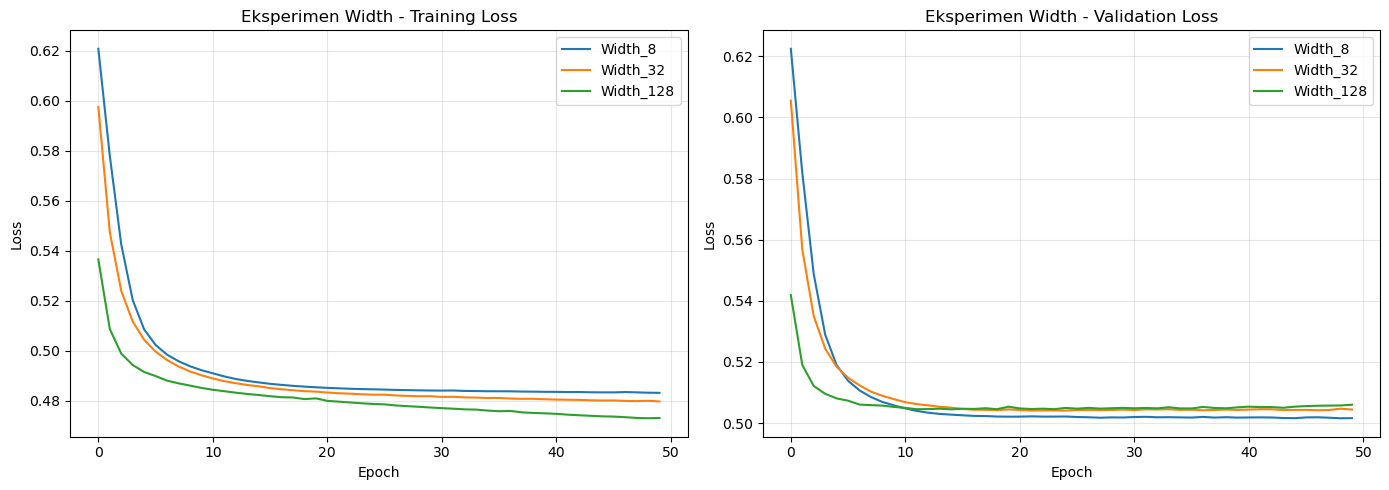

,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,width
0,Width_32,0.7565,0.781392,0.839155,0.809244,0.479683,0.504436,32
1,Width_128,0.7540,0.781846,0.832656,0.806452,0.473078,0.506012,128
2,Width_8,0.7495,0.777356,0.831032,0.803298,0.483112,0.501620,8


In [269]:
width_results = {}
widths = [8, 32, 128]

for idx, w in enumerate(widths):
    name = f"Width_{w}"
    exp_seed = SEED + 100 + idx
    model = build_network([X_train.shape[1], w, 1], activations=[ReLU()], seed=exp_seed)
    width_results[name] = run_experiment(name, model, epochs=50, lr=0.01, seed=exp_seed, width=w)

plot_history_collection(width_results, "Eksperimen Width")
display(results_to_dataframe(width_results))

Running Depth_1...
Running Depth_3...
Running Depth_5...


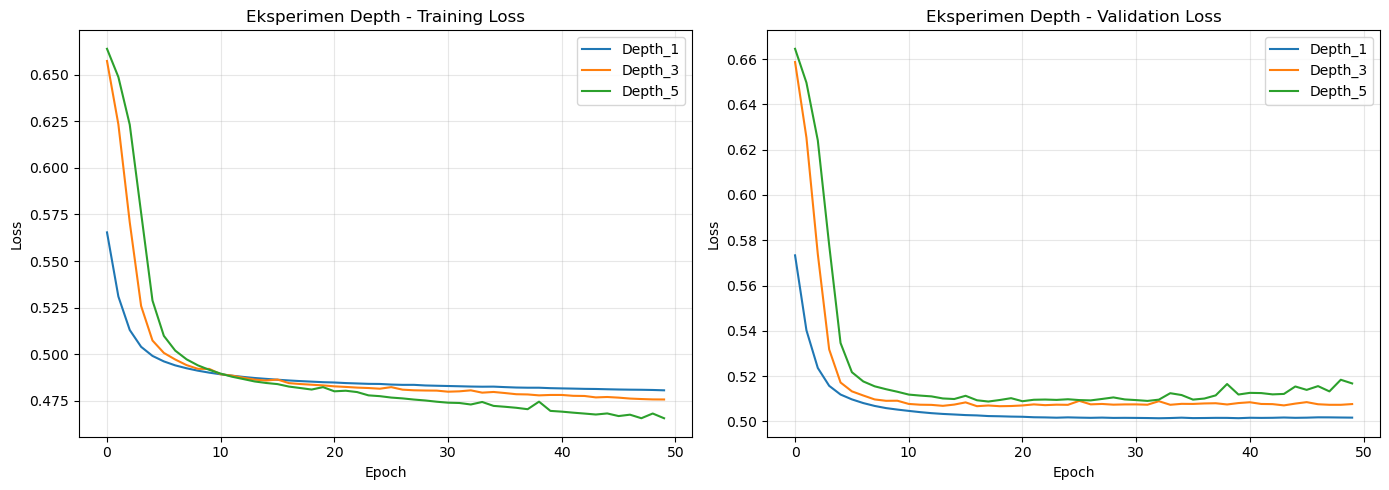

,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,depth
0,Depth_1,0.7520,0.778620,0.834281,0.805490,0.480621,0.501686,1
1,Depth_5,0.7510,0.769684,0.849716,0.807722,0.465626,0.516788,5
2,Depth_3,0.7465,0.780186,0.818846,0.799049,0.475699,0.507675,3


In [270]:
depth_results = {}
depths = [1, 3, 5]

for idx, d in enumerate(depths):
    name = f"Depth_{d}"
    exp_seed = SEED + 200 + idx
    layers = [X_train.shape[1]] + [32] * d + [1]
    activations = [ReLU()] * d
    model = build_network(layers, activations, seed=exp_seed)
    depth_results[name] = run_experiment(name, model, epochs=50, lr=0.01, seed=exp_seed, depth=d)

plot_history_collection(depth_results, "Eksperimen Depth")
display(results_to_dataframe(depth_results))

Running Activation_ReLU...
Running Activation_Sigmoid...
Running Activation_Tanh...
Running Activation_Linear...


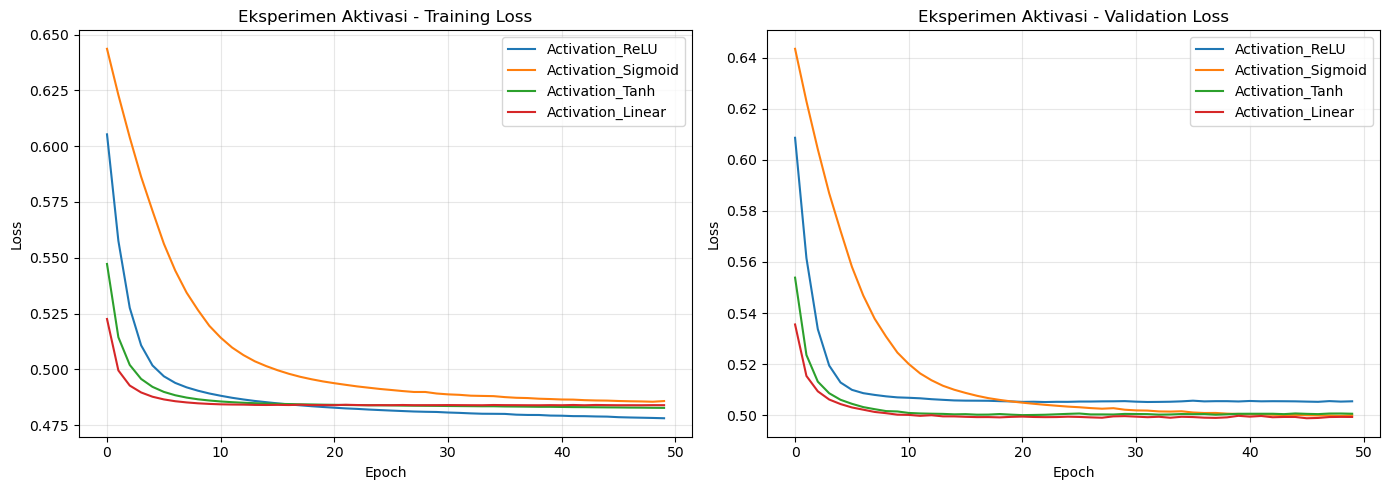

,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,test_activation
0,Activation_Sigmoid,0.7550,0.771429,0.855402,0.811248,0.485850,0.500011,Sigmoid
1,Activation_Linear,0.7540,0.774721,0.846466,0.809006,0.484004,0.499321,Linear
2,Activation_ReLU,0.7510,0.776187,0.836718,0.805317,0.478151,0.505454,ReLU
3,Activation_Tanh,0.7495,0.773204,0.839155,0.804831,0.482801,0.500587,Tanh


--- Distribusi: Activation_ReLU ---


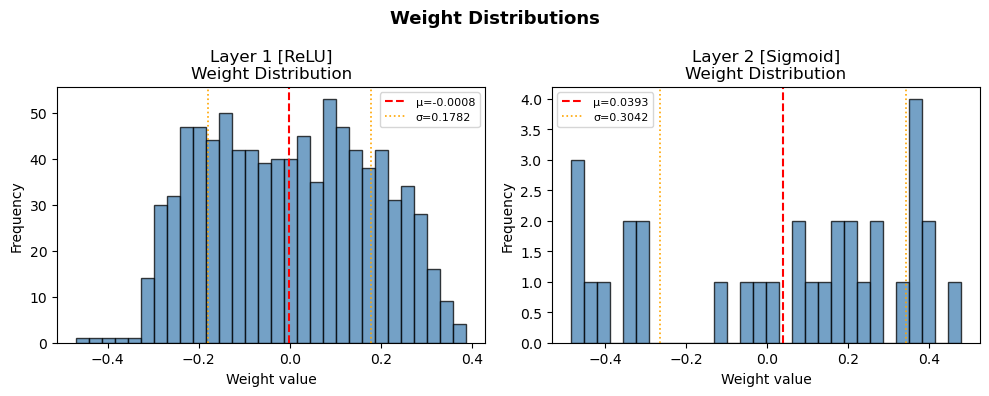

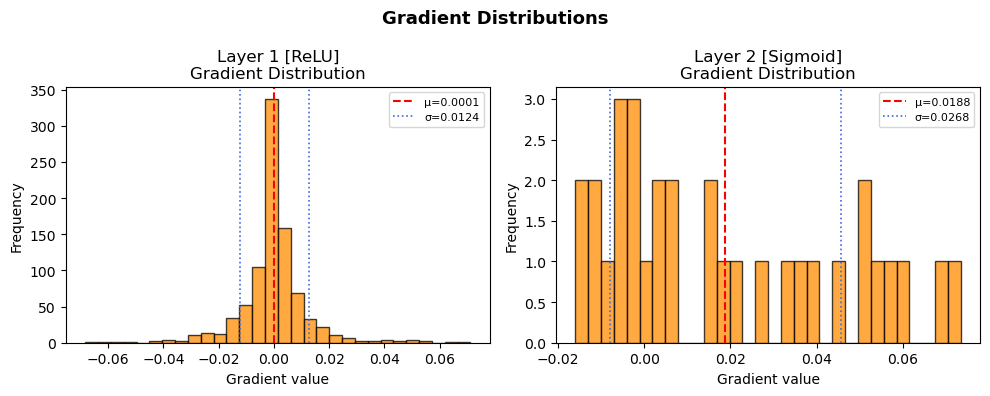

--- Distribusi: Activation_Sigmoid ---


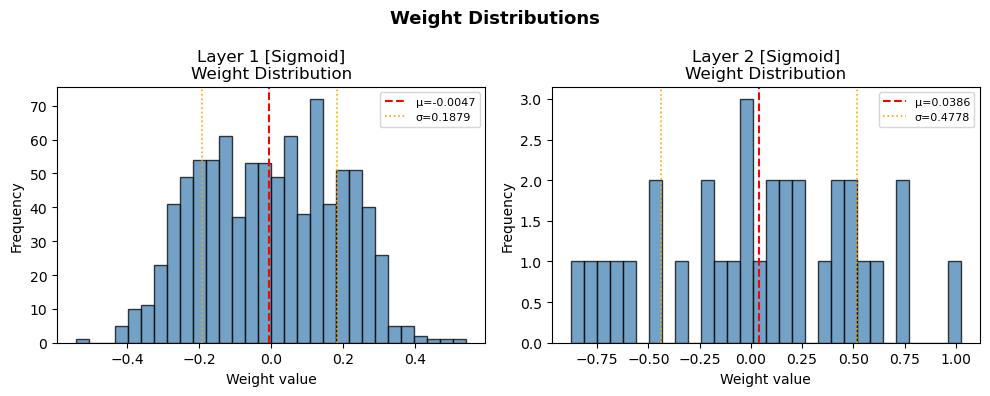

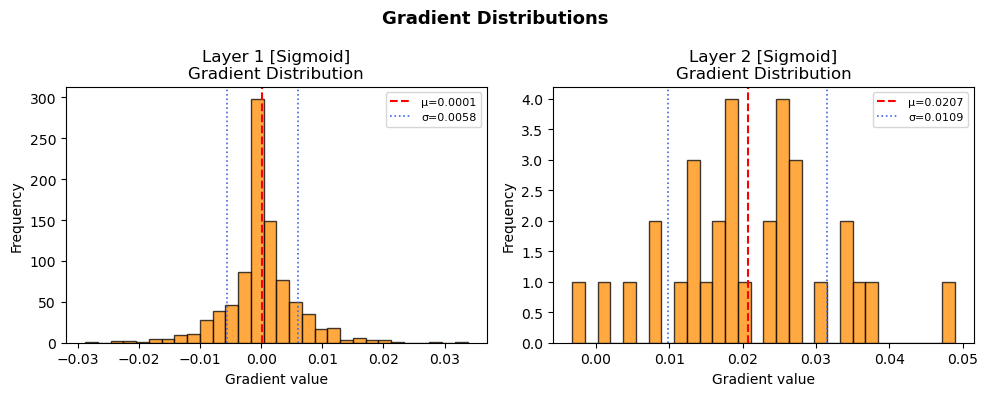

--- Distribusi: Activation_Tanh ---


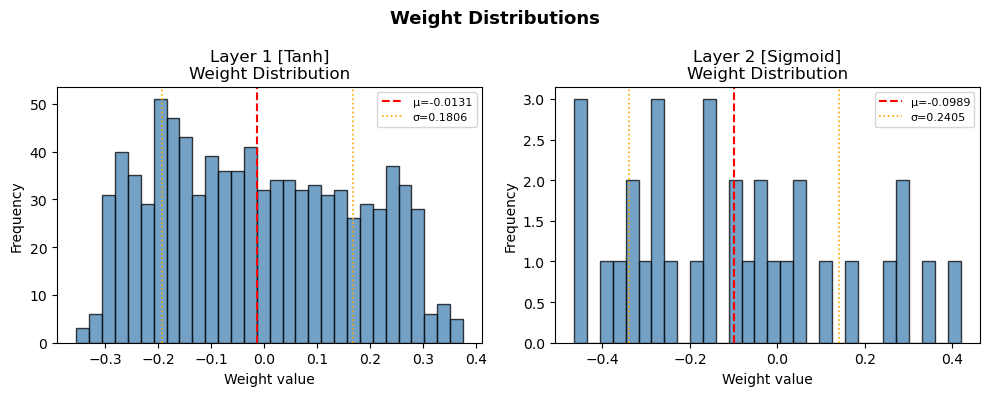

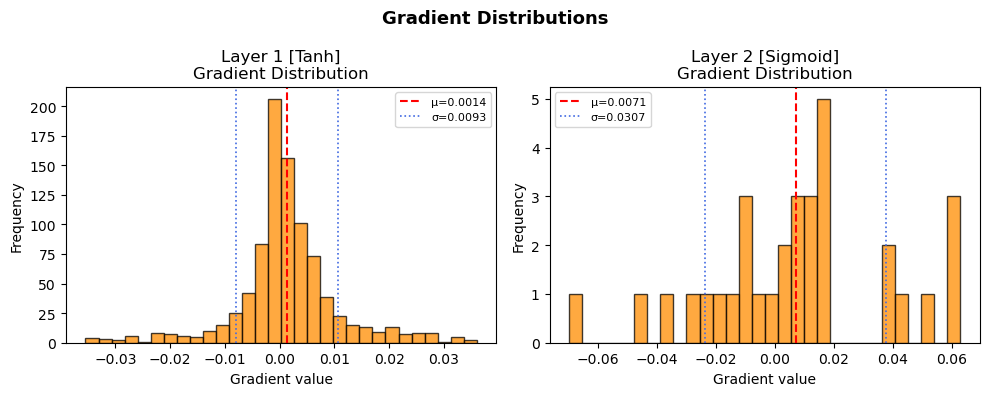

--- Distribusi: Activation_Linear ---


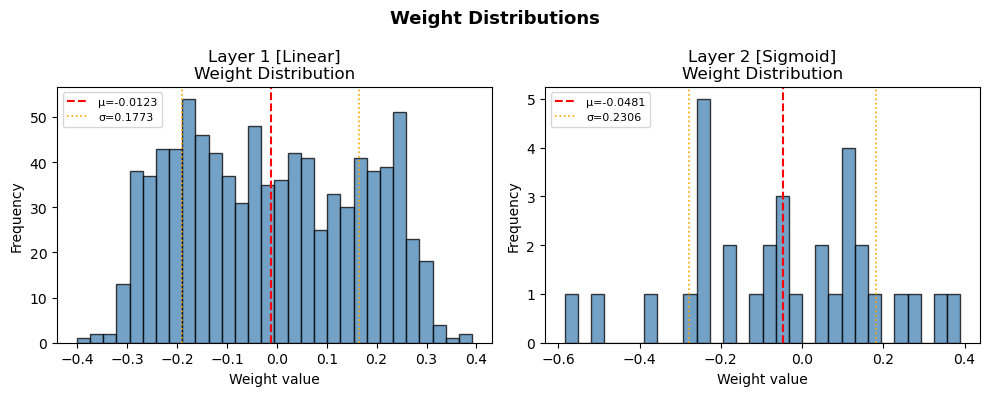

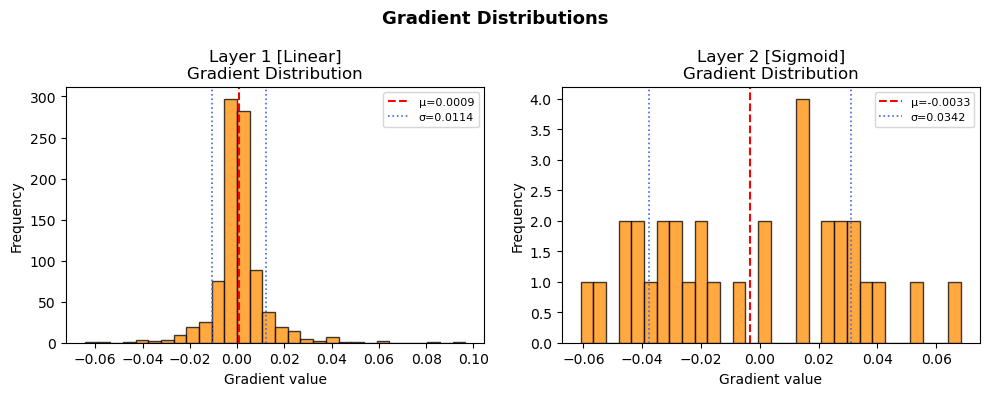

In [271]:
act_results = {}
options = {"ReLU": ReLU(), "Sigmoid": Sigmoid(), "Tanh": Tanh(), "Linear": Linear()}

for idx, (act_name, act_obj) in enumerate(options.items()):
    name = f"Activation_{act_name}"
    exp_seed = SEED + 300 + idx
    model = build_network([X_train.shape[1], 32, 1], activations=[act_obj], seed=exp_seed)
    act_results[name] = run_experiment(name, model, epochs=50, lr=0.01, seed=exp_seed, test_activation=act_name)

plot_history_collection(act_results, "Eksperimen Aktivasi")
display(results_to_dataframe(act_results))
show_distributions(act_results)

Running LR_0.1...
Running LR_0.01...
Running LR_0.001...


,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,learning_rate
0,LR_0.01,0.7555,0.782774,0.834281,0.807707,0.480058,0.502560,0.010
1,LR_0.001,0.7485,0.769630,0.844029,0.805114,0.508429,0.517698,0.001
2,LR_0.1,0.7470,0.765179,0.849716,0.805235,0.454602,0.524409,0.100


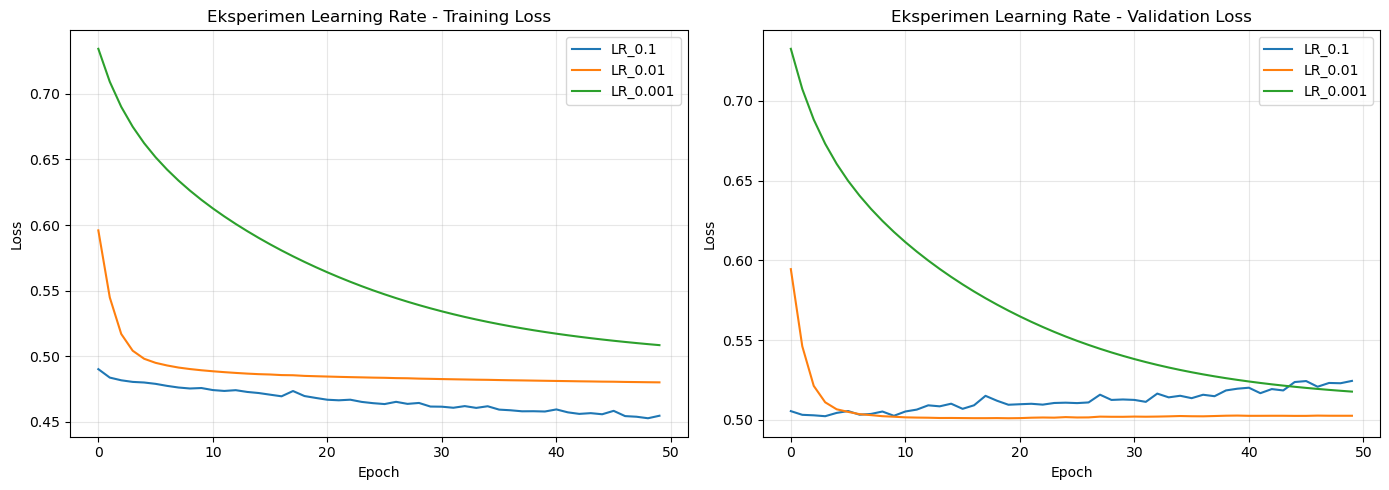

--- Distribusi: LR_0.1 ---


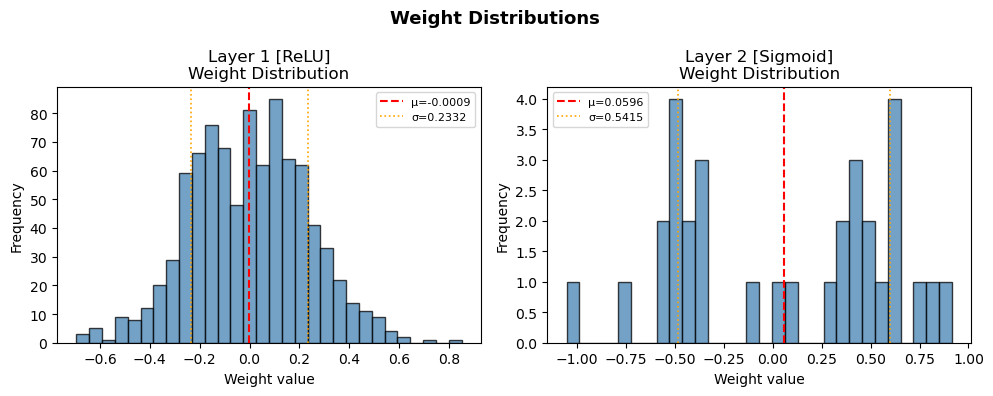

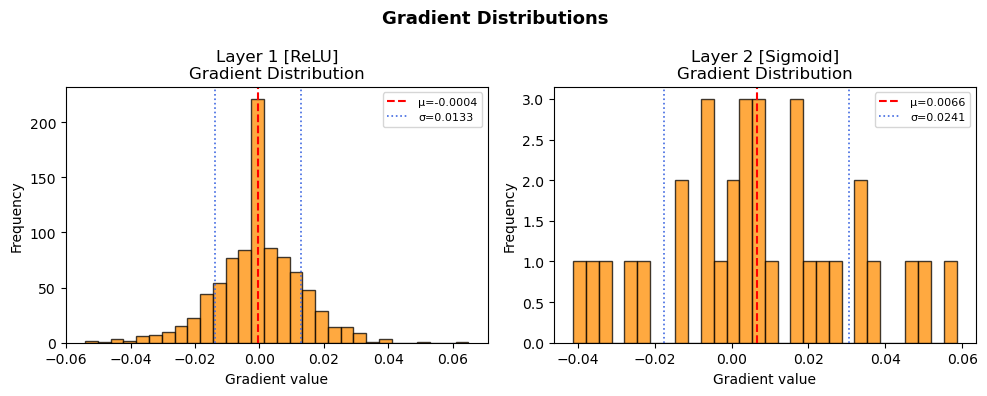

--- Distribusi: LR_0.001 ---


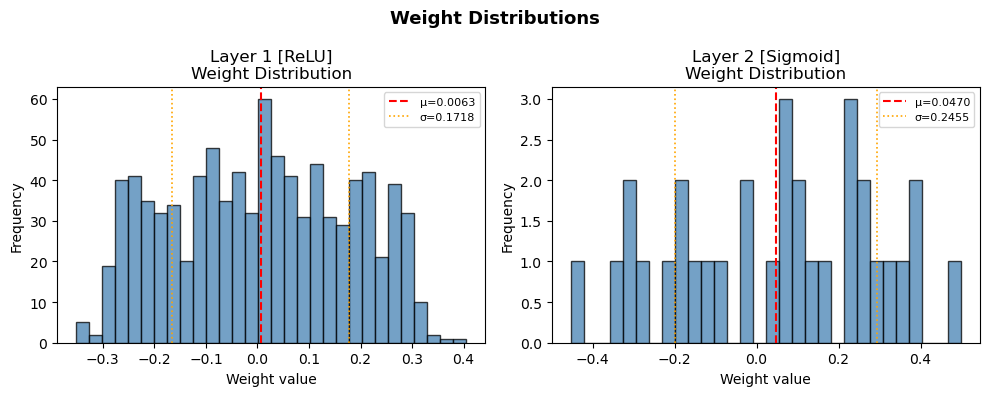

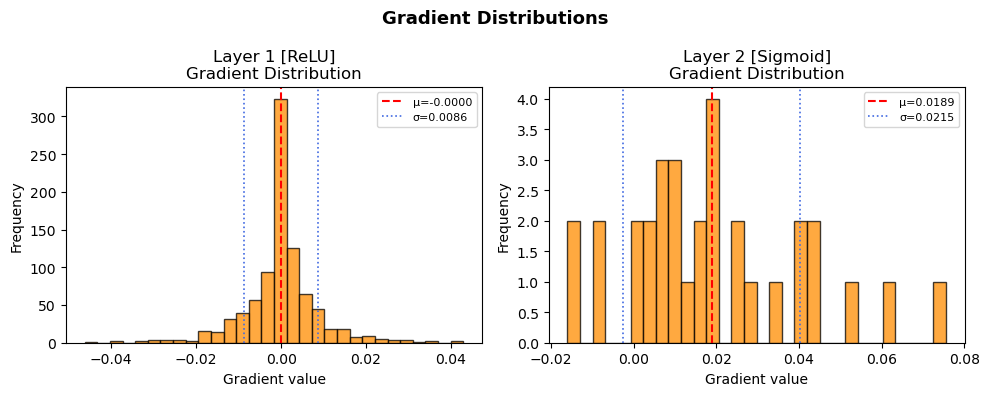

In [272]:
lr_results = {}
learning_rates = [0.1, 0.01, 0.001]

for idx, lr in enumerate(learning_rates):
    name = f"LR_{lr}"
    exp_seed = SEED + 400 + idx
    model = build_network([X_train.shape[1], 32, 1], activations=[ReLU()], seed=exp_seed)
    lr_results[name] = run_experiment(name, model, epochs=50, lr=lr, seed=exp_seed, learning_rate=lr)

display(results_to_dataframe(lr_results))
plot_history_collection(lr_results, "Eksperimen Learning Rate")
show_distributions(lr_results, names=["LR_0.1", "LR_0.001"])

Running No_Regularization...
Running L1_Regularization...
Running L2_Regularization...
Tabel Perbandingan Metrik Regularisasi:


,experiment,accuracy,precision,recall,f1,final_train_loss,final_val_loss,regularization,lambda_reg
0,L1_Regularization,0.7565,0.772328,0.857027,0.812476,0.494804,0.502524,l1,0.01
1,L2_Regularization,0.7535,0.774554,0.845654,0.808544,0.484573,0.500180,l2,0.01
2,No_Regularization,0.7530,0.780228,0.833469,0.805970,0.479162,0.505917,none,0.00


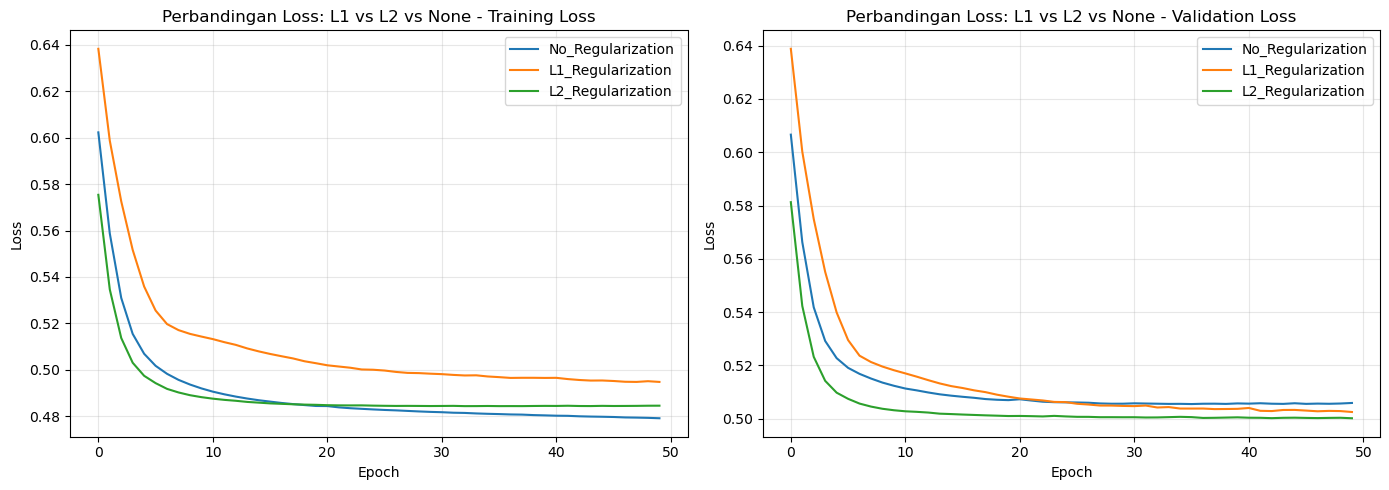

Analisis Distribusi Bobot dan Gradien:
--- Distribusi: No_Regularization ---


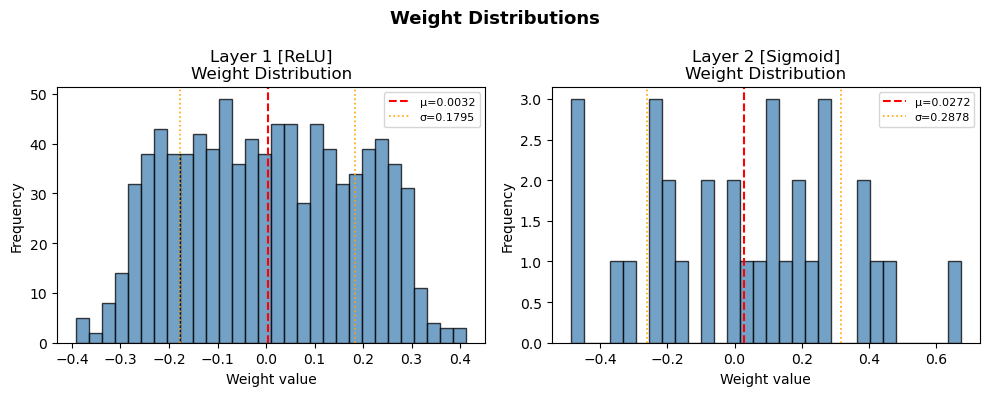

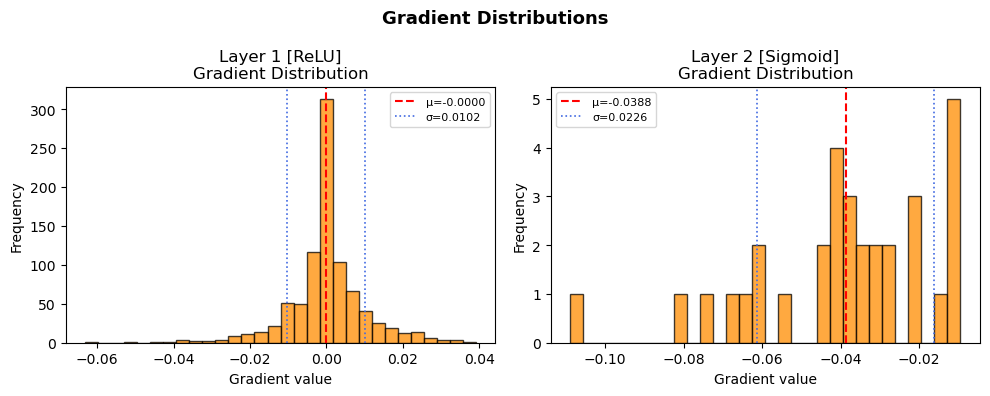

--- Distribusi: L1_Regularization ---


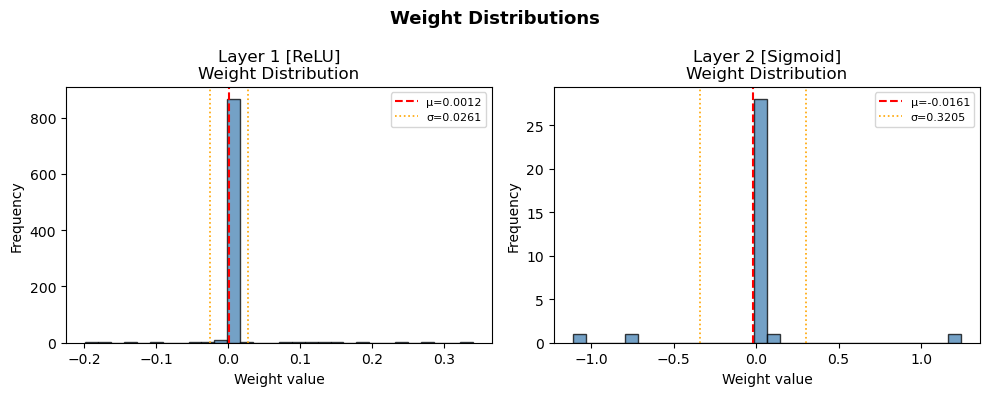

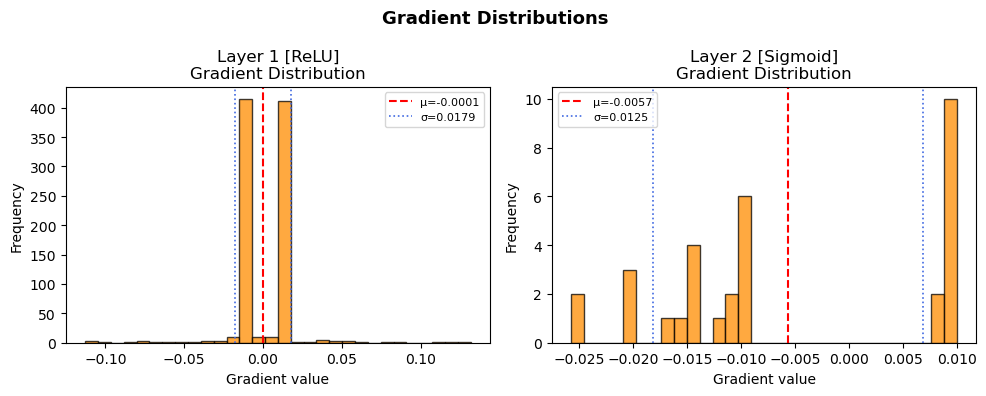

--- Distribusi: L2_Regularization ---


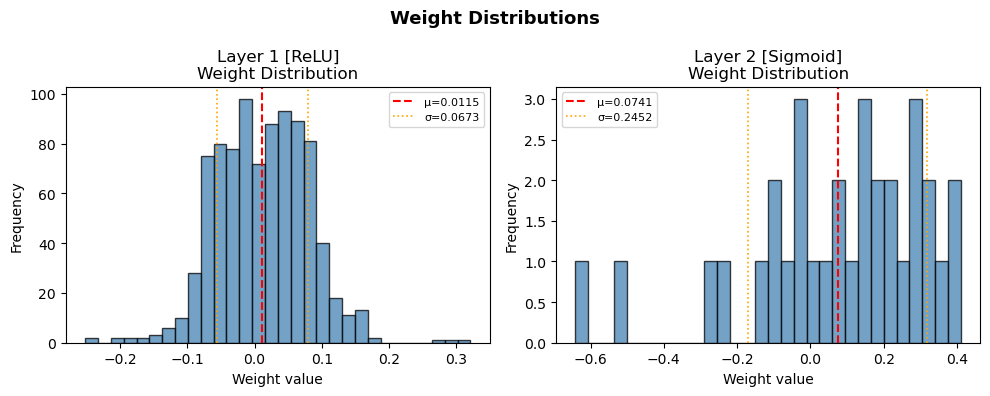

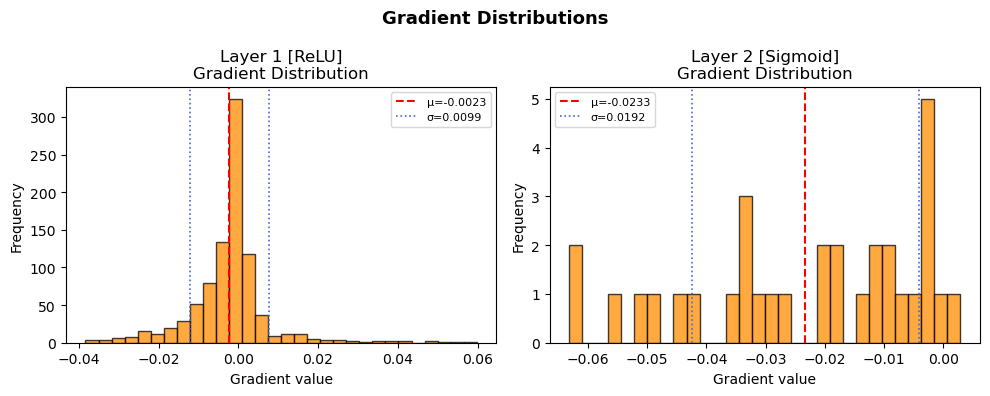

In [273]:
reg_configs = [
    {"name": "No_Regularization", "reg": None, "lambda": 0.0},
    {"name": "L1_Regularization", "reg": "l1", "lambda": 0.01},
    {"name": "L2_Regularization", "reg": "l2", "lambda": 0.01}
 ]

reg_results = {}

for idx, config in enumerate(reg_configs):
    name = config["name"]
    exp_seed = SEED + 500 + idx
    model = build_network(
        [X_train.shape[1], 32, 1],
        activations=[ReLU()],
        regularization=config["reg"],
        lambda_reg=config["lambda"],
        seed=exp_seed
    )
    reg_results[name] = run_experiment(
        name,
        model,
        epochs=50,
        lr=0.01,
        seed=exp_seed,
        regularization=config["reg"] if config["reg"] else "none",
        lambda_reg=config["lambda"]
    )

print("Tabel Perbandingan Metrik Regularisasi:")
display(results_to_dataframe(reg_results))
plot_history_collection(reg_results, "Perbandingan Loss: L1 vs L2 vs None")
print("Analisis Distribusi Bobot dan Gradien:")
show_distributions(reg_results)

In [274]:
h_params = {
    'hidden_layer_sizes': (32,),
    'activation': 'relu',
    'solver': 'sgd',
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'random_state': SEED
}

mlp_sklearn = MLPClassifier(**h_params)
mlp_sklearn.fit(X_train, y_train.ravel())
y_pred_sklearn = mlp_sklearn.predict(X_test)

custom_model = build_network([X_train.shape[1], 32, 1], activations=[ReLU()], seed=SEED + 600)
res_custom = run_experiment("Custom_Model", custom_model, epochs=50, lr=0.01, seed=SEED + 600)
y_pred_custom = res_custom["pred"]

comparison_data = {
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Custom FFNN": [
        res_custom["metrics"]["accuracy"],
        res_custom["metrics"]["precision"],
        res_custom["metrics"]["recall"],
        res_custom["metrics"]["f1"]
    ],
    "Sklearn MLP": [
        accuracy_score(y_test.reshape(-1), y_pred_sklearn),
        precision_score(y_test.reshape(-1), y_pred_sklearn, zero_division=0),
        recall_score(y_test.reshape(-1), y_pred_sklearn, zero_division=0),
        f1_score(y_test.reshape(-1), y_pred_sklearn, zero_division=0)
    ]
}

print("Hasil Perbandingan Prediksi Akhir:")
display(pd.DataFrame(comparison_data))

c:\Users\62812\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Running Custom_Model...
Hasil Perbandingan Prediksi Akhir:


,Metrik,Custom FFNN,Sklearn MLP
0,Accuracy,0.756000,0.750500
1,Precision,0.779113,0.778963
2,Recall,0.842405,0.830219
3,F1-Score,0.809524,0.803775
